# agentv7_router_agent — Router Agent

This version introduces the first true router agent.

Graph:

```text
START → router → [sql_agent | rag_agent | general_agent] → END
```

Unlike v4, routing is now done by an LLM instead of deterministic Python rules.


## Core Idea

A router agent decides which specialist agent should handle the request.

Example routes:
- `sql` → structured data / database questions
- `rag` → document lookup questions
- `general` → normal chat / reasoning


In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv
cwd=Path.cwd()
load_dotenv(cwd/'.env'); load_dotenv(cwd.parent/'.env')
print(bool(os.getenv("OPENAI_API_KEY")))


True


## Define State


In [2]:
from typing import Literal, TypedDict

RouteName = Literal["sql", "rag", "general"]

class AgentState(TypedDict, total=False):
    input: str
    route: RouteName
    answer: str


## Create Router LLM


In [3]:
from langchain_openai import ChatOpenAI
router_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


## Router Node

The LLM returns only one route:
- sql
- rag
- general


In [4]:
def router_node(state: AgentState) -> AgentState:
    prompt = f'''
Classify the user request into exactly one route:
sql = database, SQL, analytics, BI queries
rag = documents, PDFs, retrieval, knowledge base
general = everything else

Return only one word: sql or rag or general

User request: {state["input"]}
'''
    response = router_llm.invoke(prompt).content.strip().lower()

    if "sql" in response:
        route = "sql"
    elif "rag" in response:
        route = "rag"
    else:
        route = "general"

    return {"route": route}


## Specialist Agents


In [5]:
agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def sql_agent(state: AgentState) -> AgentState:
    return {"answer": f"SQL Agent selected. Request: {state['input']}"}

def rag_agent(state: AgentState) -> AgentState:
    return {"answer": f"RAG Agent selected. Request: {state['input']}"}

def general_agent(state: AgentState) -> AgentState:
    response = agent_llm.invoke(state["input"])
    return {"answer": response.content}


## Build Graph


In [6]:
from langgraph.graph import START, END, StateGraph

def route_selector(state: AgentState):
    return state["route"]

def build_graph():
    g = StateGraph(AgentState)

    g.add_node("router", router_node)
    g.add_node("sql_agent", sql_agent)
    g.add_node("rag_agent", rag_agent)
    g.add_node("general_agent", general_agent)

    g.add_edge(START, "router")

    g.add_conditional_edges(
        "router",
        route_selector,
        {
            "sql":"sql_agent",
            "rag":"rag_agent",
            "general":"general_agent"
        }
    )

    g.add_edge("sql_agent", END)
    g.add_edge("rag_agent", END)
    g.add_edge("general_agent", END)

    return g.compile()

graph = build_graph()


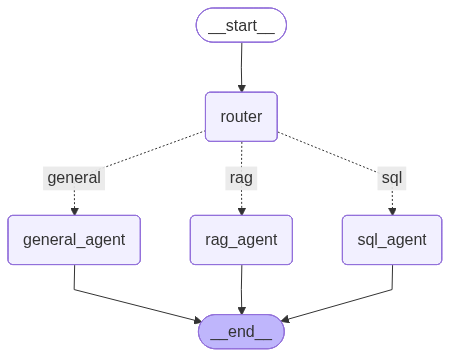

In [8]:
graph

## Visualize Graph


In [7]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	sql_agent(sql_agent)
	rag_agent(rag_agent)
	general_agent(general_agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -. &nbsp;general&nbsp; .-> general_agent;
	router -. &nbsp;rag&nbsp; .-> rag_agent;
	router -. &nbsp;sql&nbsp; .-> sql_agent;
	general_agent --> __end__;
	rag_agent --> __end__;
	sql_agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Test SQL Route


In [9]:
graph.invoke({"input":"Show SQL query for top 10 customers by revenue"})


{'input': 'Show SQL query for top 10 customers by revenue',
 'route': 'sql',
 'answer': 'SQL Agent selected. Request: Show SQL query for top 10 customers by revenue'}

## Test RAG Route


In [10]:
graph.invoke({"input":"Search PDF documents for LangGraph checkpointing"})


{'input': 'Search PDF documents for LangGraph checkpointing',
 'route': 'rag',
 'answer': 'RAG Agent selected. Request: Search PDF documents for LangGraph checkpointing'}

## Test General Route


In [11]:
graph.invoke({"input":"Explain LangGraph briefly"})


{'input': 'Explain LangGraph briefly',
 'route': 'general',
 'answer': 'LangGraph is a framework designed to enhance natural language processing (NLP) tasks by leveraging graph-based representations of language. It integrates concepts from graph theory with language models to improve the understanding and generation of text. By representing words, phrases, or sentences as nodes and their relationships as edges, LangGraph allows for more nuanced analysis of linguistic structures and semantics. This approach can facilitate various applications, such as information retrieval, text summarization, and sentiment analysis, by capturing the complex interconnections within language data.'}

## Why v7 Matters

This is the foundation for:
- Supervisor agents
- Multi-agent systems
- Agent-to-Agent communication
- Specialist orchestration

v4 used rule-based routing.
v7 uses LLM-based routing.
